# Lab 052 · TabR: learn what to retrieve

[Lesson](../lessons/0052-tabr-retrieval.html) · [Reference](../reference/tabr-retrieval.html)

**Skill:** implement and audit kNN attention. **Scope:** complete numeric TabR-S (linear encoder, one predictor block), Equation 5; binary classification and regression. Full TabR feature embeddings, categorical inputs, context freeze and multiclass output are not implemented.

Four TODO functions feed the actual training experiment. PROVIDED means read/run; CHECK gives immediate feedback; EXIT asks you to explain both the mechanism and its evidence limits. Author-reference figures are already measured snapshots, separate from your live outputs.

**Reproducibility contract:** Tier A, authors' California Housing, House 16H and Higgs Small arrays and original splits. Local row caps 1200/600/600; label-blind subsample seeds 52/53/54, model seeds 0/1/2; train-only normal quantiles and regression target scaling; 25-epoch neural cap, 150-tree cap. No quantile jitter or tuning search. Local versus paper verdict: **INCOMPARABLE**. Environment versions and file hashes are printed. The bootstrap downloads dependencies; a first data fetch retrieves about 14 MB in verified byte ranges from the authors' archive.

**Recall first:** Why are three model seeds not three independent datasets? Write one sentence before proceeding. Estimated compute is about one CPU minute after setup; allow much longer for implementation and explanation.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

In [ ]:
# PROVIDED — environment and data provisioning
import os,sys,math,hashlib,json,copy,time,platform,types,importlib.metadata
from pathlib import Path
os.environ['OMP_NUM_THREADS']='1';os.environ['OPENBLAS_NUM_THREADS']='1'
os.environ.setdefault('MPLCONFIGDIR','/tmp/relational-matplotlib')
import numpy as np
import torch
from torch import nn
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
torch.set_num_threads(1)
for candidate in (Path.cwd(),Path.cwd()/'labs',Path.cwd().parent):
    if (candidate/'relkit').is_dir():
        LABS=candidate.resolve();os.chdir(LABS);sys.path.insert(0,str(LABS));break
else:raise RuntimeError('Run inside the repository or use the Colab bootstrap')
from _fetch_l052 import fetch
fetch()
print({p:importlib.metadata.version(p) for p in ['torch','numpy','scipy','scikit-learn','xgboost']})
print('Dataset manifest SHA256:',hashlib.sha256((LABS/'_data_l052.json').read_bytes()).hexdigest())

## 1. What changes when a model keeps a memory?




A **parametric** predictor stores the information it learned in its parameters: weights and biases. After fitting, an ordinary MLP maps the new row’s features directly to a prediction. A **retrieval-augmented** predictor also consults a collection of stored examples. The collection is its **candidate memory**; the examples selected for one prediction are its **context**. In TabR the usual candidates are labeled training rows. The query is the row we want to predict, not its unknown target.




Ordinary **k-nearest neighbors** selects k nearby rows under a chosen distance and averages their targets or votes for their classes. TabR learns both the space used to decide “nearby” and how a neighbor contributes. Its output is not simply the neighbors’ mean label. A neural representation of the query remains present, and a neural prediction head processes that representation together with the retrieved evidence. See [§3.2](https://ar5iv.labs.arxiv.org/html/2307.14338#S3.S2).




This is a useful response to a difficulty from L051: if the target changes over short distances, a single global mapping may be harder to fit than a mapping that can consult nearby examples. That is a motivation, not a guarantee. A learned distance can select unhelpful neighbors, labels can be noisy, and a training neighborhood can differ from what deployment permits.






| Method | Interaction unit | Information at prediction |
| --- | --- | --- |
| FT-Transformer | Feature tokens within a row | Query features and trained parameters |
| SAINT row attention | Rows in the evaluation context | Depends on the specified context protocol |
| TabR | Retrieved training rows | Query features, trained parameters, legal memory features and labels |






For a fixed memory, TabR predictions need not depend on unrelated queries placed in the same inference batch. We check that property. TabR is still a single-table baseline: learned proximity is not a foreign-key relationship, and retrieving a row does not reconstruct database structure.

### The fitted object contains a memory as well as weights

An ordinary parametric predictor evaluates fθ(x) after training has compressed useful information into θ. A retrieval model evaluates fθ(x;M), where M is an explicit collection of eligible examples. Changing M can change a prediction while every parameter stays fixed. Saving only a weight file is therefore insufficient to reproduce its behavior.

For supervised retrieval, memory entries contain features, labels and identities. Labels are valuable because they provide local evidence; they are also why eligibility matters. A held-out target must not enter the memory that predicts it. A duplicate feature vector from a different legitimate training row is a different issue from retrieving the query's own labeled record.

TabR learns a geometry in which useful neighbors can be selected. It is not simply k-nearest neighbors on standardized raw features, and its neighbor values are not merely scalar targets. The encoder shapes both which records become neighbors and how their information contributes after selection.

Think of the prediction as three questions. **Where should I look?** Compute keys and select nearby memory records. **What should I take from them?** Combine their labels with a learned function of the key difference. **How should I use the result?** Add the aggregated context to the query representation and pass it through the prediction network.

This decomposition suggests useful ablations. Freeze the learned geometry and replace the value function; keep values fixed and change context size; retain the query network while withholding retrieved context. Each changes a distinct route. Comparing the full model only with a standalone MLP cannot by itself identify which retrieval component caused a gain.

## 2. Model architecture




We implement the complete **numeric TabR-S** variant from §4: no numerical feature embeddings, a linear encoder, one retrieval module and one residual predictor block. Full TabR additionally allows richer input embeddings and encoder/predictor choices. We do not claim to implement those variants. Binary classification and regression are supported; categorical input and multiclass prediction are outside this lab.




The encoder E applies a shared affine map, `h = Ax + b`, after preprocessing. “Shared” means that the query and candidates pass through the same parameters; they live in the same representation space. The key map K applies another affine map. Retrieval produces a vector r with the same d coordinates as h, so we can add them: `z = h + r`. This **residual connection** preserves a route from the query to the prediction even if retrieved evidence contributes little.




The predictor block normalizes z across its d coordinates using LayerNorm, expands d→2d, applies ReLU and dropout, contracts 2d→d, then adds its input. ReLU sets negative coordinates to zero. Dropout randomly zeroes activations during training and rescales survivors; it is disabled during evaluation. The head applies LayerNorm, ReLU and a final linear map. For binary classification its scalar is a **logit**, converted to a probability by `σ(a)=1/(1+exp(−a))`. For regression it predicts a standardized target, converted back to original units for RMSE.




There is no separate pretraining stage. Both supervised training and inference use retrieval. The training loss compares each prediction with its known target, but that target must not enter the same query’s retrieved context. Validation chooses when to stop; held-out test targets enter only the final metric.

<div style="overflow-x:auto;max-width:100%">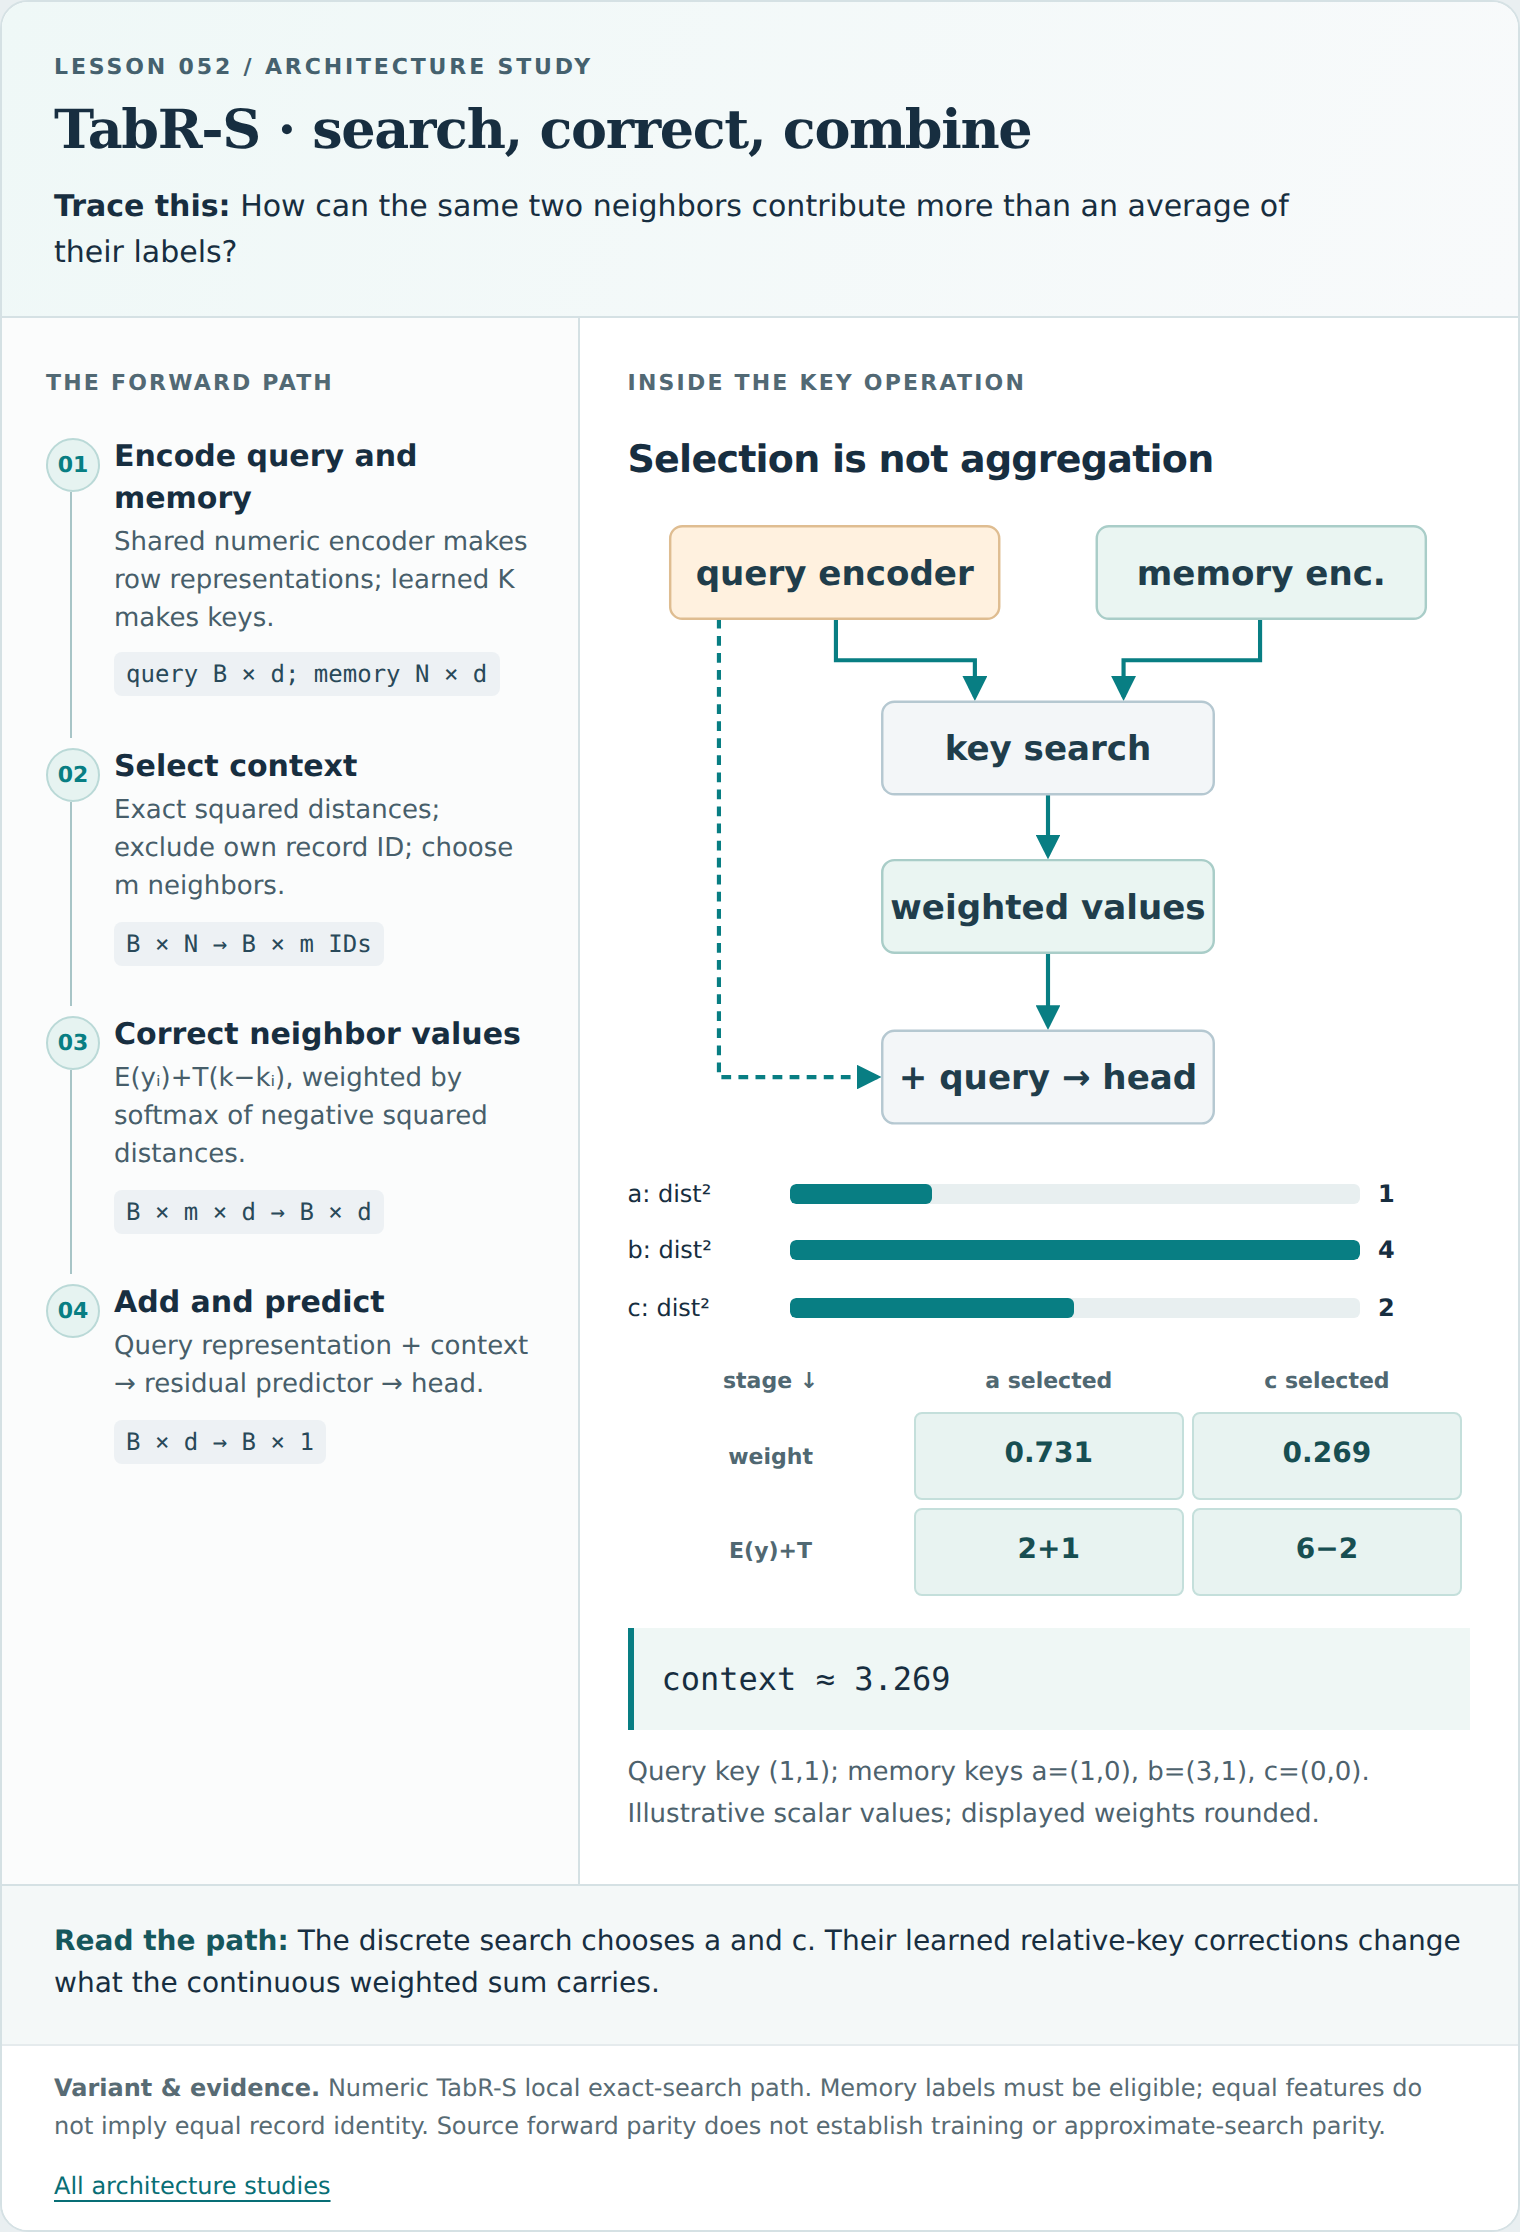</div>

*Portable architecture figure. On a narrow notebook screen, scroll horizontally to retain readable labels.* [Open the responsive diagram](https://avistian.github.io/relational/labs/html/architecture-review/0052-tabr.html).

**Read the path:** The discrete search chooses a and c. Their learned relative-key corrections change what the continuous weighted sum carries.

**Variant and evidence:** Numeric TabR-S local exact-search path. Memory labels must be eligible; equal features do not imply equal record identity. Source forward parity does not establish training or approximate-search parity.

## 3. Learn a distance, then select a context




Write k for the query key and kᵢ for candidate i’s key, each a vector of length d. Equation 5 assigns the score `sᵢ = −‖k−kᵢ‖² = −Σⱼ(kⱼ−kᵢⱼ)²`. The square removes the sign of each coordinate difference; the sum combines differences across coordinates; the minus sign makes close candidates score higher. Select the m eligible rows with the largest scores. The discrete top-m operation returns row indices.




A dot product rewards alignment and can reward large vector norms. Squared distance asks for closeness. For k=(1,0), candidate a=(10,0) has dot product 10 but squared distance 81; candidate b=(1,1) has dot product 1 but squared distance 1. Dot product prefers a; TabR’s distance prefers b. These are genuinely different neighbor rules, not two ways of writing the same attention.




The learned key map also matters. If K(h)=Wh+b, then `K(h)−K(hᵢ)=W(h−hᵢ)`: the shared bias cancels in the distance. W can stretch, shrink and mix directions, changing what counts as a neighbor. In TabR-S, two affine maps compose into an affine map, so this key geometry is learned but not itself a nonlinear feature embedding. The nonlinear value module and predictor still make the full model nonlinear.




Convert selected scores into **softmax weights**: `pᵢ = exp(sᵢ) / Σⱼ∈context exp(sⱼ)`. The denominator runs over the selected context, not every training row. Before dropout, these weights are nonnegative and sum to one. Final TabR omits the Transformer-style `1/√d` multiplier. Its learned key scale therefore also controls how concentrated the weights become. Do not copy Equation 3’s scaling into the final Equation 5 model.




**Predict before moving the control:** a query at key 1 has two legal nearest neighbors at keys 0 and 2. What are their weights? What happens if the query’s own row becomes eligible?




With self excluded, both scores are −1 and each weight is 0.5. With self included, its score is 0. It receives about 0.731 of the top-two weight, already a strong direct path from the target to the prediction. In larger learned spaces the contrast can become much sharper. Equal-distance ties can be resolved differently by search libraries; our source parity cases avoid cutoff ties, and the illustrated widget uses row order.




**How can training work through top-m?** The selected indices are discrete: we do not differentiate which row wins a rank comparison. Once indices are chosen, we recompute their scores and values with gradients enabled. A gradient describes how a small parameter change affects the current neighborhood’s prediction; a later optimizer step can change the neighborhood itself. Detaching all selected keys would incorrectly remove this learning route. The source audit compares outputs and input gradients against the pinned released class with copied weights.

### Trace selection and weighting separately

Let a query key be k=(1,1), and candidate keys be a=(1,0), b=(3,1), c=(0,0). Their squared distances are 1, 4 and 2. With context size two, the selected records are a and c. The attention weights normalize only over those selected records: exp(−1)/(exp(−1)+exp(−2))≈0.731 and 0.269.

Notice two operations. Top-k selection produces discrete record identities. Softmax produces continuous weights conditional on those identities. In the local implementation, selection runs without gradient tracking, then selected distances and values are recomputed through differentiable operations. A small key change can adjust the weights smoothly while the neighbor set remains fixed; crossing a selection boundary can change the set abruptly.

Unlike scaled dot-product Transformer attention, this weighting uses negative squared distances without a 1/√d factor. Scaling every key by two multiplies squared distances by four and sharpens the resulting weights. Key scale is therefore part of the learned retrieval behavior, not a harmless unit conversion.

The implementation excludes self-matches using record identity. Suppose two legitimate records have equal feature vectors. Excluding every equal vector would remove both; excluding the query's ID removes only its own labeled entry. These are different policies with different effects on repeated or discretized data.

Stable tie handling makes a small fixture reproducible, but it does not eliminate the statistical consequences of ties. With identical keys and a context budget smaller than the tie group, the selected subset depends on the declared ordering policy. Preserve memory ordering or use an explicit deterministic tie-break when exact reproducibility matters.

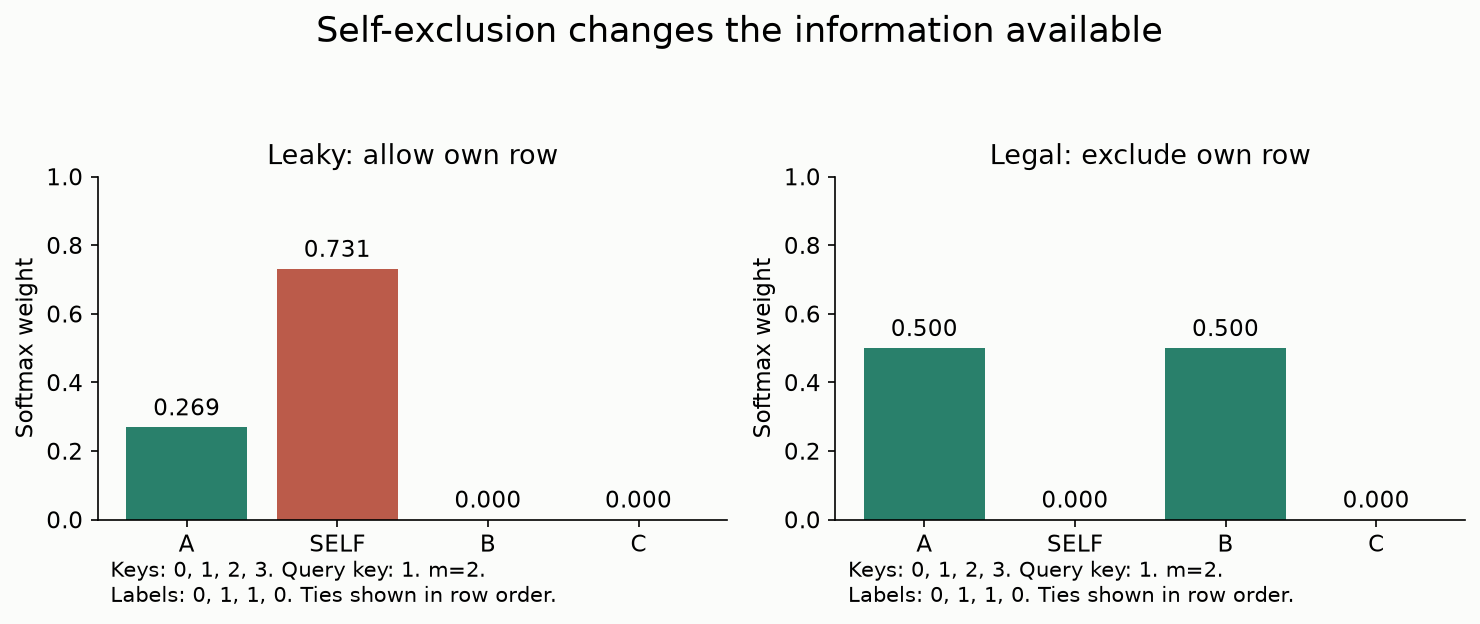

Synthetic top-2 attention at query key 1. Excluding the identical row ID removes the direct target path; equal feature vectors with distinct IDs remain separate candidates.

### TODO 1 · Legal identities
Implement a boolean matrix of shape [queries,candidates]. Entry (i,j) is true exactly when the query and candidate IDs differ. Support arbitrary candidate ordering. Do not compare feature vectors.

In [ ]:
# TODO — implement the live function
def eligible_mask(query_ids, candidate_ids):
    raise NotImplementedError("Build the legal identity matrix")

In [ ]:
# CHECK — reordered IDs, repeated feature values irrelevant
assert eligible_mask(torch.tensor([9,3]),torch.tensor([3,7,9])).tolist()==[[True,True,False],[False,True,True]]
assert eligible_mask(torch.tensor([8]),torch.tensor([1,2,3])).all()
print('Identity boundary PASS')

### TODO 2 · Discrete legal neighbors
Compute squared distances between every query and candidate key. Inside a no-gradient region, make illegal distances ineligible and return the m nearest indices per query. Raise ValueError if m is invalid or any query has too few legal candidates. Gradients will be reconstructed on selected keys in the model.

In [ ]:
# TODO — implement the live function
def select_neighbors(keys, candidate_keys, m, allowed):
    raise NotImplementedError("Select m legal nearest indices")

In [ ]:
# CHECK — more than the illustrated example, and no silent illegal fallback
q=torch.tensor([[0.,0.],[2.,0.]])
c=torch.tensor([[2.,0.],[0.,0.],[0.,0.]])
mask=eligible_mask(torch.tensor([9,3]),torch.tensor([3,7,9]))
assert select_neighbors(q,c,1,mask).tolist()==[[1],[1]]
torch.manual_seed(520)
q2=torch.randn(4,5);c2=torch.randn(13,5);legal=torch.ones(4,13,dtype=torch.bool);legal[:,2]=False
got=select_neighbors(q2,c2,4,legal)
brute=(q2[:,None]-c2[None]).square().sum(-1).masked_fill(~legal,torch.inf).argsort(dim=1)[:,:4]
assert torch.equal(got,brute)
try:select_neighbors(q,c,3,mask)
except ValueError:pass
else:raise AssertionError('Illegal context must fail')
print('Neighbor selection PASS')

## 4. A neighbor contributes more than its label




TabR’s value is `vᵢ = Wᵧ(yᵢ) + T(k−kᵢ)`. The **label encoder** Wᵧ maps a known candidate target into d coordinates: an embedding lookup for classification, an affine map of a scalar for regression. An embedding is a learned vector associated with a discrete class. The **correction network** T translates a query-minus-neighbor key difference into that same d-dimensional value space.




The order of the subtraction matters. k−kᵢ describes where the query lies relative to that neighbor. Reversing it changes the input to a nonlinear function; it is not an innocuous distance calculation. The released T is Linear→ReLU→Dropout→LinearWithoutBias. The first linear layer has a bias, so the architecture does *not* guarantee T(0)=0. Nor is T constrained to be a derivative or a calibrated scalar label correction.





The scalar illustration uses Wᵧ(y)=y and T(Δk)=βΔk only to expose the arithmetic. At query 1, neighbor A has key 0 and label 0, while B has key 2 and label 1. At β=0.5, their corrected values are `0+0.5(1−0)=0.5` and `1+0.5(1−2)=0.5`. With equal weights their sum is 0.5. Moving β changes the individual contributions but leaves this symmetric aggregate unchanged: the corrections cancel. Predicting “every internal change must alter the output” would miss that cancellation.




In the real model, retrieval returns `r = Σᵢ dropout(p)ᵢ vᵢ`. Dropout acts on softmax weights and does not renormalize them. Thus weights sum to one during evaluation, but need not sum to one in a training pass. Values are vectors, not class probabilities, and the head receives h+r, not r alone. A single highly weighted neighbor is useful diagnostic evidence, not a complete causal explanation of the final output.




Why use both features and labels? A label says what happened to a neighbor; the difference vector says how that neighbor differs from the query. The paper motivates the latter through local correction, inspired by DNNR. Its regression projection study in Appendix A.2 supports a role for corrections along the label-embedding direction; that specific result should not be generalized into an identical classification finding. See [Appendix A.2](https://ar5iv.labs.arxiv.org/html/2307.14338#A1.S2).

### Why the key difference belongs in the value

For selected record i, the local TabR-S value has the form E(yᵢ)+T(k−kᵢ). E embeds the neighbor target into the hidden space. T is a learned transformation of the directed key difference. The sign matters: T(k−kᵢ) need not equal T(kᵢ−k), because the transformation is not constrained to be an even function.

The target embedding says what happened at the neighbor. The difference term lets the model adjust that evidence according to how the query differs from the neighbor. This makes retrieval richer than averaging nearby labels. It can learn that a neighbor is informative while still requiring a directional correction before its information is useful at the query.

Use a one-coordinate illustration, distinct from the full learned network. Let two target embeddings be 2 and 6, and let their learned difference contributions at this query be +1 and −2. The values are then 3 and 4. With the previous weights 0.731 and 0.269, the aggregated context is approximately 3.269. Averaging target embeddings alone would give approximately 3.076. The same neighbors and weights can therefore produce different representations because the value function changed.

The context vector is added to the encoded query representation, so the downstream predictor can combine direct feature evidence with retrieved evidence. It is not forced to copy the nearest label. This residual route is also why a retrieval model may remain useful when neighbors are imperfect.

During training, dropout on context weights can remove individual contributions. Standard dropout scales retained entries but does not renormalize each realized weight vector to sum to one. At evaluation, dropout is disabled. Do not interpret every training-time context vector as a convex average simply because the pre-dropout softmax weights sum to one.

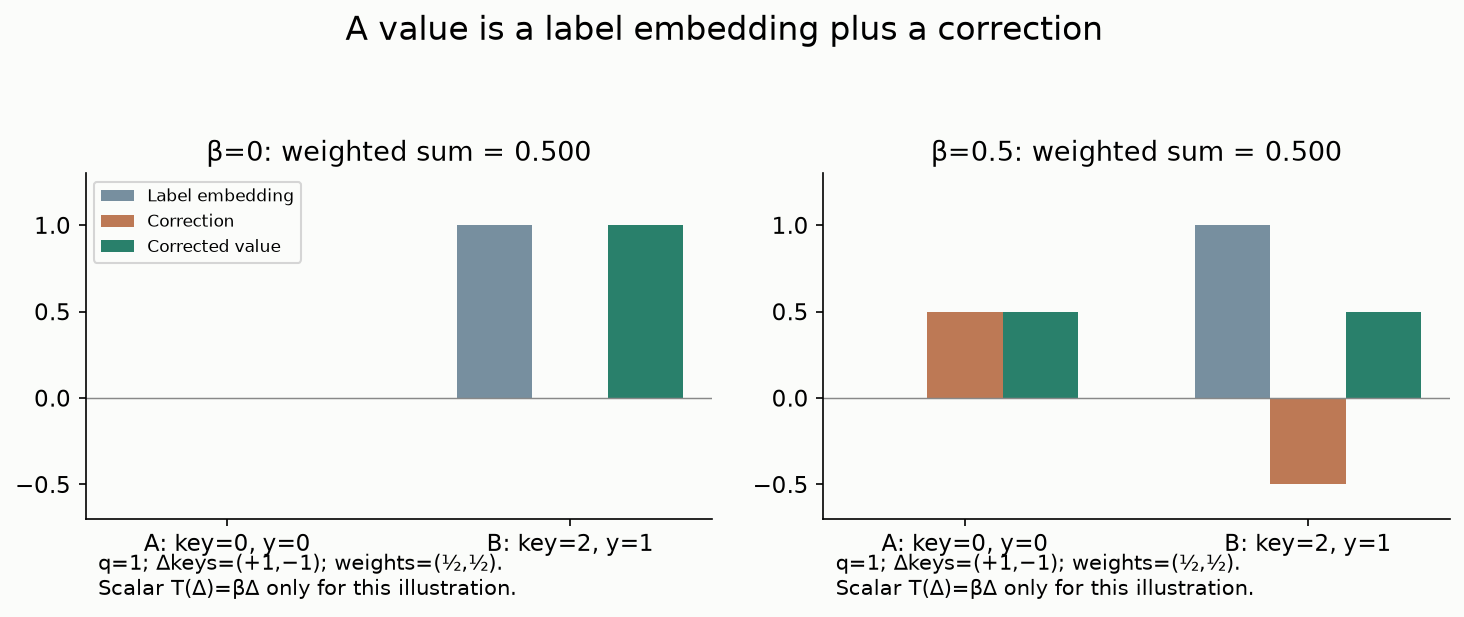

Synthetic scalar illustration: changing β changes per-neighbor values; equal weights and opposite key differences make the corrections cancel in the sum.

### TODO 3 · Corrected vector values
Return one d-dimensional value per selected neighbor. Add the supplied label embeddings to the supplied correction module evaluated on the correctly directed key difference. Broadcasting must work for B queries and m neighbors.

In [ ]:
# TODO — implement the live function
def context_value(keys, neighbor_keys, label_embeddings, correction):
    raise NotImplementedError("Construct Eq. 5 values")

In [ ]:
# CHECK — direction, shape, and gradient access
q=torch.tensor([[1.,2.]],requires_grad=True)
n=torch.tensor([[[0.,0.],[2.,3.]]],requires_grad=True)
e=torch.tensor([[[0.,1.],[1.,0.]]])
v=context_value(q,n,e,nn.Identity())
torch.testing.assert_close(v,torch.tensor([[[1.,3.],[0.,-1.]]]))
v.sum().backward();assert q.grad.abs().sum()>0 and n.grad.abs().sum()>0
print('Directed values and gradients PASS')

### TODO 4 · Weights and aggregation
Compute negative squared distance over the key dimension, normalize over the neighbor dimension, apply the supplied dropout module, then return the weighted sum of vector values. Do not insert dimension scaling or renormalize after dropout. The checks include an asymmetric neighborhood where using the wrong softmax axis is detectable.

In [ ]:
# TODO — implement the live function
def aggregate_context(keys, neighbor_keys, values, dropout):
    raise NotImplementedError("Weight and sum the context")

In [ ]:
# CHECK — asymmetric weights, translation invariance, dropout semantics
q=torch.tensor([[0.,0.]]);n=torch.tensor([[[0.,0.],[1.,0.]]]);v=torch.tensor([[[2.,-1.],[0.,3.]]])
w=torch.tensor([1.,math.exp(-1)]);w=w/w.sum()
expected=(v*w[None,:,None]).sum(1)
torch.testing.assert_close(aggregate_context(q,n,v,nn.Identity()),expected)
torch.testing.assert_close(aggregate_context(q+3,n+3,v,nn.Identity()),expected)
class Twice(nn.Module):
    def forward(self,x):return 2*x
torch.testing.assert_close(aggregate_context(q,n,v,Twice()),2*expected)
print('Aggregation PASS')

### PROVIDED · Complete model around your four functions
The linear input map, learned keys, label encoder, correction network, residual block and prediction head are all visible below. Calls resolve to your current function definitions; nothing imports a hidden replacement model.

In [ ]:
class TabRS(nn.Module):
    def __init__(self, n_features, d=32, m=16, multiplier=2,
                 dropout=0.1, context_dropout=0.1, regression=False,
                 retrieval=True):
        super().__init__()
        self.m, self.regression, self.retrieval = m, regression, retrieval
        h = int(d * multiplier)
        self.linear = nn.Linear(n_features, d)
        self.K = nn.Linear(d, d)
        self.label_encoder = nn.Linear(1, d) if regression else nn.Embedding(2, d)
        self.T = nn.Sequential(nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout),
                               nn.Linear(h, d, bias=False))
        self.context_dropout = nn.Dropout(context_dropout)
        self.block = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, h), nn.ReLU(),
                                   nn.Dropout(dropout), nn.Linear(h, d), nn.Dropout(0.0))
        self.head = nn.Sequential(nn.LayerNorm(d), nn.ReLU(), nn.Linear(d, 1))
        if regression:
            nn.init.uniform_(self.label_encoder.weight, -1/math.sqrt(2), 1/math.sqrt(2))
            nn.init.uniform_(self.label_encoder.bias, -1/math.sqrt(2), 1/math.sqrt(2))
        else:
            nn.init.uniform_(self.label_encoder.weight, -1, 1)

    def forward(self, x, candidate_x, candidate_y, query_ids=None, candidate_ids=None):
        representation = self.linear(x)
        if self.retrieval:
            keys = self.K(representation)
            candidate_keys = self.K(self.linear(candidate_x))
            allowed = torch.ones((len(x), len(candidate_x)), dtype=torch.bool, device=x.device)
            if query_ids is not None:
                if candidate_ids is None:
                    raise ValueError('Candidate identities are required with query identities')
                allowed = eligible_mask(query_ids, candidate_ids)
            indices = select_neighbors(keys, candidate_keys, self.m, allowed)
            neighbor_keys = candidate_keys[indices]
            labels = candidate_y[indices]
            label_embeddings = self.label_encoder(labels[..., None] if self.regression else labels.long())
            values = context_value(keys, neighbor_keys, label_embeddings, self.T)
            representation = representation + aggregate_context(keys, neighbor_keys, values, self.context_dropout)
        representation = representation + self.block(representation)
        return self.head(representation).squeeze(-1)

In [ ]:
# CHECK — live model: query batching and memory order do not change predictions
torch.manual_seed(52)
model=TabRS(3,d=8,m=3,dropout=0,context_dropout=0).eval()
x=torch.randn(9,3);y=torch.arange(9)%2;ids=torch.arange(9)
batch=model(x[:2],x,y,ids[:2],ids)
single=torch.cat([model(x[i:i+1],x,y,ids[i:i+1],ids) for i in range(2)])
torch.testing.assert_close(batch,single)
perm=torch.randperm(9)
torch.testing.assert_close(batch,model(x[:2],x[perm],y[perm],ids[:2],ids[perm]))
changed=y.clone();changed[0]=1-changed[0]
torch.testing.assert_close(batch[:1],model(x[:1],x,changed,ids[:1],ids))
print('Live model protocol PASS')

## 5. The memory is part of the evaluation protocol




A training-only candidate table is necessary for the IID lab. It is not always sufficient for a deployment claim. There are three distinct checks.


**Split boundary:** validation and test labels cannot enter memory, preprocessing, model fitting or hyperparameter selection. Validation labels select the checkpoint; test labels score it once.**Identity boundary:** when a training row is a query, exclude that exact row from candidates. Compare stable row IDs, not feature equality. Two rows with identical features are not automatically the same row; whether duplicates are legitimate is a separate data audit.**Availability boundary:** a historical row’s target may not have been known at the query’s prediction time. Filter by when the target became available, and by any entity/group exclusions required by deployment.



A sale observed on day 2 may have a “returned within 30 days” target that becomes known much later. On day 4, “the event already happened” does not make that target available. For a real prediction-time memory, record both event time and label-availability time. The diagram uses strict earlier-than semantics; an application must explicitly define its handling of equal timestamps. This extends the paper’s [Appendix B](https://ar5iv.labs.arxiv.org/html/2307.14338#A2) requirement that training retrieval simulate deployment.




Our lab uses the authors’ supplied IID partitions. The availability diagram is a synthetic protocol exercise, not a measured temporal benchmark. Neither the local scores nor source parity establishes performance for future customers, unseen entities or future periods.




Memory also has a computational cost. Exact search for B queries over N candidates of width d requires work proportional to BNd; a full epoch over N training queries can therefore involve N² distance work. This does not mean all candidate pairs exchange attention in one forward pass. After selection, values cost roughly Bm times the cost of T. The released code uses Faiss exact search; this small lab uses PyTorch distances. At fixed trained weights, candidate keys can be cached, but query-dependent values must be recomputed. The paper’s **context freeze** freezes neighbor identities after some epochs; it is not the same as freezing all representations or disabling gradients. We explain it but do not implement it here.

### A legal training memory can become an illegal serving memory

For a random held-out benchmark, a fixed training-only memory is a clear inductive contract. For deployment over time, “in the database” is not sufficient. A label must have been available before the prediction cutoff, and all retrieved features must reflect what was knowable then. Later outcome corrections can leak information if historical records are reconstructed from their current state.

Suppose an event happened Monday, its outcome arrived Thursday, and you predict on Tuesday. Its features may be eligible under the task definition, but its supervised target is unavailable. A retrieval system that uses Thursday's label while replaying Tuesday's prediction is evaluating a different information regime.

Memory refresh is another procedure choice. A frozen memory, a periodically refreshed memory and an online memory updated after labels arrive have different cost and adaptation behavior. Test the update policy you intend to deploy. Caching a stale key after changing encoder weights can also invalidate nearest-neighbor search; the memory representation must match the encoder used by the query.

For the lab, record context IDs alongside predictions on a small audit subset. Then you can answer whether a surprising prediction came from an unexpected neighbor set, a sharp weighting distribution or a downstream transformation. A score alone cannot distinguish these failure modes.

### What source parity does and does not settle

Copied-weight agreement on fixed inputs is strong evidence that the checked forward computation matches the reference path. It does not establish identical training dynamics, approximate-search behavior, preprocessing, checkpoint selection or large-scale runtime. The local exact-search numeric implementation should retain its declared scope even when its operator checks are excellent.

When comparing with a paper result, audit the memory population and context policy alongside ordinary hyperparameters. Retrieval has made the data available at prediction time part of the model definition. Omitting that field from a reproduction report omits a load-bearing component.

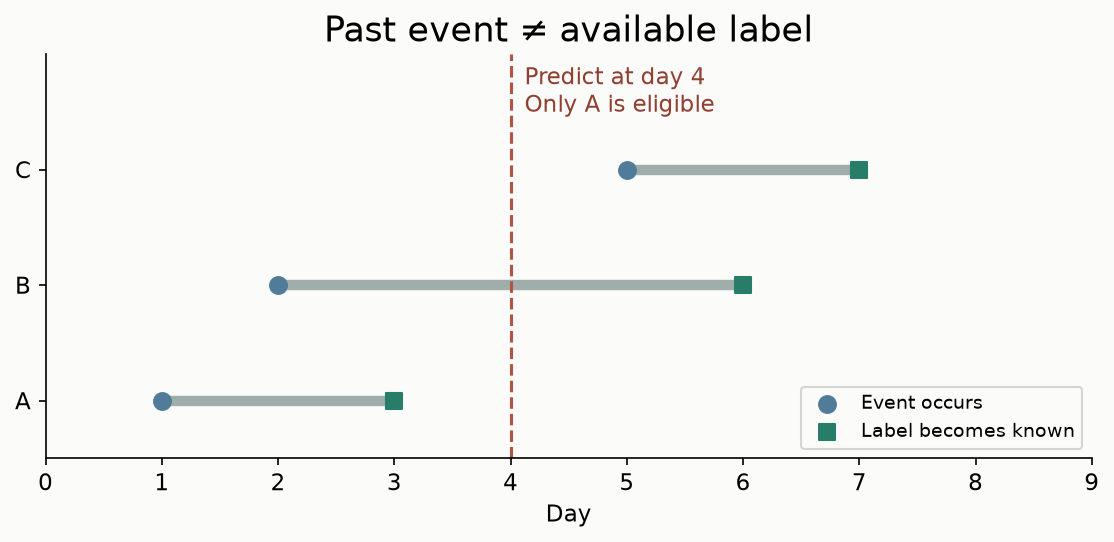

Synthetic availability check: at prediction day 4, only A has both an earlier event and an earlier known label.

### PROVIDED · Source audit boundary
The author executed the pinned released Model class with copied weights against this implementation. Four cases cover regression/classification and training/inference candidate paths. Maximum output error was 1.20e-7 and maximum input-gradient error 5.97e-8. Dropout was disabled, and a PyTorch exact-search adapter replaced Faiss. This establishes the checked neural path, not full training, preprocessing or Faiss runtime parity. See `_source_check_l052.py` and `_source_check_l052_results.json` for the reproducible audit.

## 6. What did the paper show, and what did we measure?




The paper develops the design incrementally. On California Housing, Table 2 reports RMSE 0.499 for MLP, 0.484 for the initial attention baseline, 0.489 after adding labels, 0.418 after changing the similarity, 0.408 after changing the value module, and 0.403 after the final tweaks. Lower RMSE is better. This is a source-reported design sequence with tuned configurations, not our controlled local experiment. Adding labels alone did not deliver the improvement; the way the model accessed them mattered. [Table 2](https://ar5iv.labs.arxiv.org/html/2307.14338#S3.T2).




Keep three comparisons distinct: Table 3 compares single models, averaged over 15 seeds; the simple TabR-S California target is 0.403, while full TabR is 0.400. Ensemble results average predictions of separately trained models. The 43-task comparison uses the Grinsztajn benchmark with the paper’s specified filtering and tuning protocol; it does not promise superiority on every dataset or under a tiny fixed budget. The authors also identify tree methods as a cheaper option. Read [§4](https://ar5iv.labs.arxiv.org/html/2307.14338#S4) and Appendix C.2 before quoting a headline.




**Our experiment:** Tier A data from the authors’ released archive: California Housing, House 16H and Higgs Small. Preserve original train/validation/test membership, then select 1,200 training and 600 rows per evaluation split without consulting labels. Selection seeds are 52/53/54 for train/validation/test; model seeds are 0/1/2. Median imputation, normal-quantile feature transforms and regression-target standardization are fitted on training rows only. We omit the released preprocessing’s quantile jitter and do not claim preprocessing parity.




The MLP arm uses exactly the TabR-S encoder and predictor with retrieval switched off; unused retrieval parameters receive no gradients. Both neural arms use width 32, at most 25 epochs, learning rate .001, dropout .1 and validation early stopping after eight non-improving epochs. TabR-S retrieves 16 neighbors with context dropout .1. XGBoost uses depth 4, learning rate .05, at most 150 trees and validation early stopping. These are fixed recipes with one candidate per arm, not matched wall-clock budgets or a recreation of the paper’s tuning.







| Dataset / metric | MLP | TabR-S | XGBoost |
| --- | --- | --- | --- |
| california / RMSE | 0.5932 ± 0.0076 95% CI [0.5743, 0.6121] | 0.5882 ± 0.0059 95% CI [0.5735, 0.6029] | 0.5398 ± 0.0017 95% CI [0.5357, 0.5439] |
| house / RMSE | 40202 ± 209 95% CI [39682, 40722] | 38196 ± 165 95% CI [37785, 38607] | 37762 ± 375 95% CI [36830, 38693] |
| higgs-small / accuracy | 0.5883 ± 0.0142 95% CI [0.5530, 0.6237] | 0.5856 ± 0.0285 95% CI [0.5148, 0.6563] | 0.6972 ± 0.0167 95% CI [0.6558, 0.7387] |





Mean ± sample SD across three seeds; t intervals (2 degrees of freedom) condition on the fixed split and sampled rows. Mean ranks: MLP 2.667, TabR-S 2.333, XGBoost 1.000. Friedman p=0.0970; Nemenyi CD=1.9136. No pair exceeds the critical difference. The observed tree lead is descriptive; this small rank test does not establish a general winner. Training elapsed 40.8 seconds on the author CPU; this is not a model-speed benchmark.






We additionally permute stored training labels at inference while keeping the fitted model, candidate features, query features and neighbor selection fixed. This measures dependence on the memory’s label alignment. It is *not* a retrained “no labels” ablation, because the model is being evaluated under a changed input distribution. The notebook prints both scores and asks you to explain that distinction.




**Conclusion boundary:** these measurements describe a small-data fixed-budget regime. A local loss does not refute the large benchmark; a local win would not reproduce it. All comparisons with the paper remain **INCOMPARABLE**. For the relational thesis, TabR raises the baseline bar, while supplying no direct relational-versus-flat evidence.

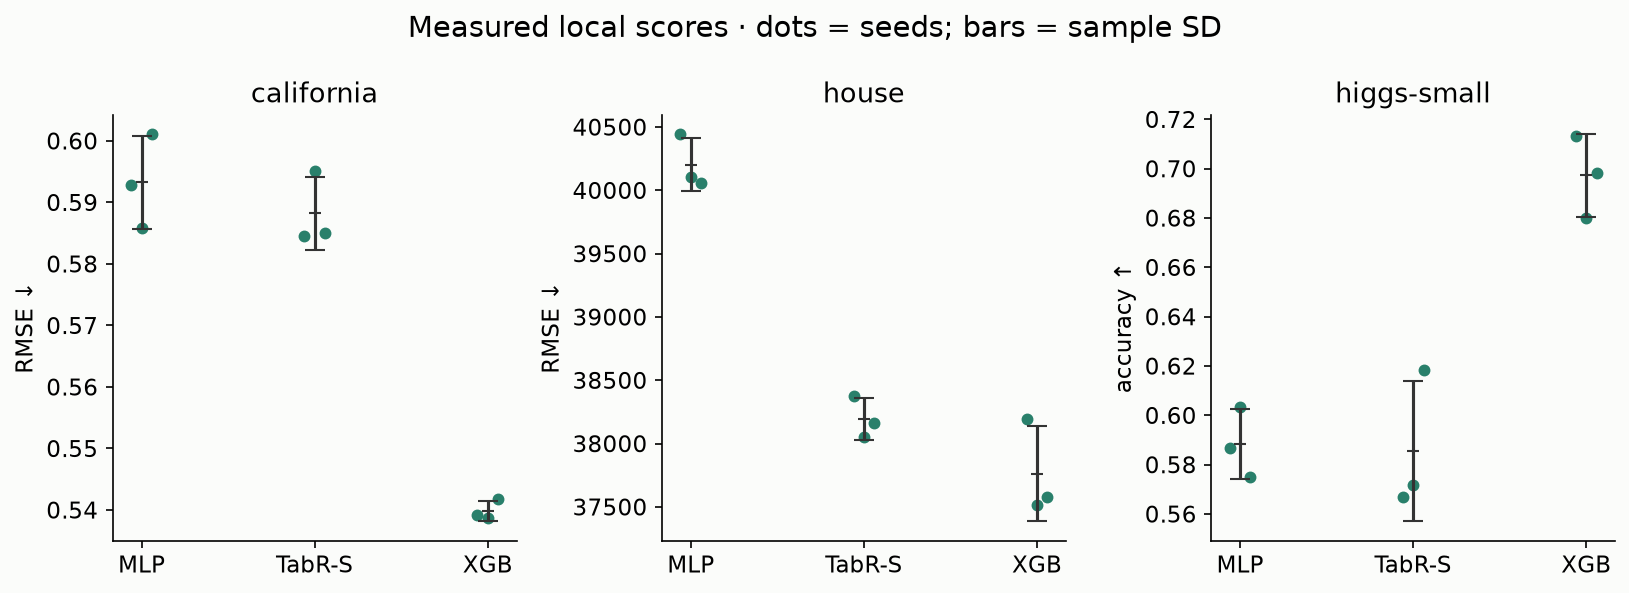

Author-reference measurements. Dots are three model seeds; error bars are sample SD. These are fixed-split local results, not paper metrics.

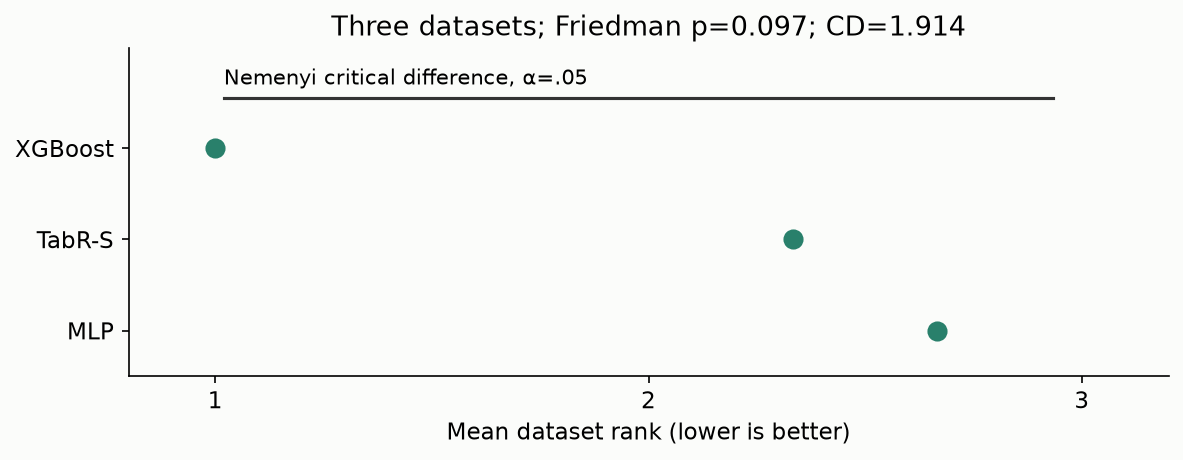

Author-reference mean ranks with Nemenyi CD over three datasets. Nonsignificance does not establish equivalence.

### PROVIDED · Visible preprocessing, training and evaluation
Read `load_task`: transforms fit only on the training subset. Read `fit_neural`: training supplies row IDs for self-exclusion; validation/test queries see only the training memory. Validation chooses the checkpoint. `run_suite` receives your live TabRS class and calls it in each fit.

**Predict before running:** does the label-shuffling intervention estimate what a model trained without labels would achieve? Explain why not, then run.

In [ ]:
"""Visible L052 training protocol; the supplied model class is the live notebook class."""
import copy
import hashlib
import importlib.metadata
import json
import platform
import time
from pathlib import Path
import numpy as np
import torch
from torch import nn
from scipy.stats import rankdata, friedmanchisquare, studentized_range, t
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import accuracy_score, mean_squared_error
from xgboost import XGBClassifier, XGBRegressor
from threadpoolctl import threadpool_limits


def load_task(name, train_cap=1200, eval_cap=600, data_root=None):
    """Authors' splits retained; label-blind subsamples; train-only transforms."""
    root = Path(data_root or 'data/cache/l052') / name
    arrays, labels, selection = {}, {}, {}
    for j, split in enumerate(('train', 'val', 'test')):
        x = np.load(root/f'X_num_{split}.npy'); y = np.load(root/f'Y_{split}.npy')
        cap = train_cap if split == 'train' else eval_cap
        ids = np.random.default_rng(52+j).permutation(len(x))[:min(cap or len(x),len(x))]
        arrays[split], labels[split], selection[split] = x[ids], y[ids], ids.tolist()
    median = np.nanmedian(arrays['train'],axis=0)
    for s in arrays: arrays[s] = np.where(np.isnan(arrays[s]),median,arrays[s])
    transform = QuantileTransformer(n_quantiles=min(1000,len(arrays['train'])),
                                    output_distribution='normal',random_state=52)
    transform.fit(arrays['train'])
    arrays = {s:transform.transform(x).astype('float32') for s,x in arrays.items()}
    regression = name != 'higgs-small'
    mean = float(labels['train'].mean()) if regression else 0.
    std = float(labels['train'].std()) if regression else 1.
    if std == 0: raise ValueError('Constant training target')
    labels = {s:((y-mean)/std).astype('float32') for s,y in labels.items()}
    return dict(x=arrays,y=labels,regression=regression,target_mean=mean,target_std=std,selection=selection)


def score_predictions(prediction, target, regression, target_std):
    return float(np.sqrt(mean_squared_error(target,prediction))*target_std if regression
                 else accuracy_score(target, prediction>0))


def seed_interval(values):
    values = np.asarray(values,dtype=float)
    mean = float(values.mean()); sd = float(values.std(ddof=1)) if len(values)>1 else 0.
    half = float(t.ppf(.975,len(values)-1)*sd/np.sqrt(len(values))) if len(values)>1 else None
    return dict(mean=mean,sd=sd,ci95=None if half is None else [mean-half,mean+half],n=len(values))


def fit_neural(model_class, data, seed, *, d=32, m=16, epochs=25, lr=.001,
               dropout=.1, context_dropout=.1, retrieval=True, device='cpu', patience=8):
    torch.manual_seed(seed)
    model = model_class(data['x']['train'].shape[1],d=d,m=m,dropout=dropout,
                        context_dropout=context_dropout,regression=data['regression'],retrieval=retrieval).to(device)
    xs = {s:torch.tensor(x,device=device) for s,x in data['x'].items()}
    ys = {s:torch.tensor(y,device=device) for s,y in data['y'].items()}
    ids = torch.arange(len(xs['train']),device=device)
    optimizer = torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=0.)
    best, best_state, history, stale = float('inf'), None, [], 0
    def predict(split, candidate_y=None):
        model.eval()
        with torch.no_grad():
            return torch.cat([model(batch,xs['train'],ys['train'] if candidate_y is None else candidate_y)
                              for batch in xs[split].split(256)]).cpu().numpy()
    for epoch in range(epochs):
        model.train()
        for batch_ids in torch.randperm(len(ids),device=device).split(256):
            logits = model(xs['train'][batch_ids],xs['train'],ys['train'],batch_ids,ids)
            loss = (nn.functional.mse_loss(logits,ys['train'][batch_ids]) if data['regression']
                    else nn.functional.binary_cross_entropy_with_logits(logits,ys['train'][batch_ids]))
            if not torch.isfinite(loss): raise RuntimeError('Nonfinite training loss')
            optimizer.zero_grad();loss.backward();optimizer.step()
        prediction = predict('val')
        score = score_predictions(prediction,data['y']['val'],data['regression'],data['target_std'])
        objective = score if data['regression'] else -score
        history.append(score)
        if objective < best:
            best, best_state, stale = objective, copy.deepcopy(model.state_dict()), 0
        else: stale += 1
        if stale >= patience: break
    model.load_state_dict(best_state)
    test_prediction = predict('test')
    result = dict(seed=seed,score=score_predictions(test_prediction,data['y']['test'],data['regression'],data['target_std']),
                  prediction=test_prediction.tolist(),validation_history=history,best_epoch=int(np.argmin(history) if data['regression'] else np.argmax(history))+1)
    if retrieval:
        # Inference intervention, not a retrained ablation: same keys, different stored labels.
        shuffled = ys['train'][torch.as_tensor(np.random.default_rng(52).permutation(len(ids)),device=device)]
        altered = predict('test',shuffled)
        result['shuffled_label_score'] = score_predictions(altered,data['y']['test'],data['regression'],data['target_std'])
    return result


def run_suite(model_class, *, names=('california','house','higgs-small'), seeds=(0,1,2),
              train_cap=1200, eval_cap=600, d=32, m=16, epochs=25, trees=150,
              lr=.001, dropout=.1, context_dropout=.1, patience=8, device='cpu',
              data_root='data/cache/l052', arms=('MLP','TabR-S','XGBoost')):
    torch.set_num_threads(1)
    start = time.time(); results = {}
    with threadpool_limits(limits=1):
        for name in names:
            data = load_task(name,train_cap,eval_cap,data_root)
            runs = {a:[] for a in arms}
            for seed in seeds:
                for arm in arms:
                    if arm != 'XGBoost':
                        run = fit_neural(model_class,data,seed,d=d,m=m,epochs=epochs,lr=lr,
                                         dropout=dropout,context_dropout=context_dropout,
                                         patience=patience,retrieval=arm=='TabR-S',device=device)
                    else:
                        cls = XGBRegressor if data['regression'] else XGBClassifier
                        tree = cls(n_estimators=trees,max_depth=4,learning_rate=.05,subsample=.8,
                                   colsample_bytree=.8,n_jobs=1,random_state=seed,tree_method='hist',early_stopping_rounds=16)
                        tree.fit(data['x']['train'],data['y']['train'],eval_set=[(data['x']['val'],data['y']['val'])],verbose=False)
                        prediction = tree.predict(data['x']['test']) if data['regression'] else tree.predict_proba(data['x']['test'])[:,1]-.5
                        run = dict(seed=seed,score=score_predictions(prediction,data['y']['test'],data['regression'],data['target_std']),prediction=prediction.tolist(),best_epoch=int(tree.best_iteration)+1)
                    runs[arm].append(run)
                    print(name,seed,arm,round(run['score'],5),flush=True)
            results[name] = dict(metric='RMSE' if data['regression'] else 'accuracy',
                target_std=data['target_std'],test_target=data['y']['test'].tolist(),selection=data['selection'],
                runs=runs,summary={a:seed_interval([r['score'] for r in rr]) for a,rr in runs.items()})
    stats = None
    if len(names)>=3 and len(arms)>=3:
        scores = np.array([[r['summary'][a]['mean']*(1 if r['metric']=='RMSE' else -1) for a in arms] for r in results.values()])
        ranks = np.array([rankdata(row) for row in scores]); k=len(arms);n=len(names)
        stats = dict(arms=list(arms),mean_ranks=ranks.mean(0).tolist(),dataset_ranks=ranks.tolist(),
                     friedman_p=float(friedmanchisquare(*ranks.T).pvalue),
                     cd=float(studentized_range.ppf(.95,k,np.inf)/np.sqrt(2)*np.sqrt(k*(k+1)/(6*n))))
    return dict(results=results,stats=stats,elapsed_seconds=time.time()-start,
                versions={p:importlib.metadata.version(p) for p in ['torch','numpy','scipy','scikit-learn','xgboost']},
                hardware=platform.machine()+' '+device,verdict='INCOMPARABLE',
                protocol=dict(train_cap=train_cap,eval_cap=eval_cap,seeds=list(seeds),subsample_seed=52,
                    split='author-provided; no resplitting',d=d,m=m,epochs=epochs,trees=trees,lr=lr,
                    dropout=dropout,context_dropout=context_dropout,patience=patience,
                    preprocessing='train median and normal quantiles; train target standardization; no quantile jitter',arms=list(arms)))

In [ ]:
# PROVIDED — measured live run, about one CPU minute in the author environment
live_results=run_suite(TabRS,data_root=LABS/'data/cache/l052')
rows=[]
for name,task in live_results['results'].items():
    for arm,summary in task['summary'].items():
        rows.append(dict(dataset=name,metric=task['metric'],model=arm,**summary))
display(pd.DataFrame(rows))
print('Rank statistics:',live_results['stats'])
for name,task in live_results['results'].items():
    clean=[r['score'] for r in task['runs']['TabR-S']]
    changed=[r['shuffled_label_score'] for r in task['runs']['TabR-S']]
    print(name,'clean:',seed_interval(clean),'shuffled:',seed_interval(changed))

In [ ]:
# CHECK — saved predictions must reconstruct reported metrics
for name,task in live_results['results'].items():
    for arm,runs in task['runs'].items():
        for run in runs:
            reconstructed=score_predictions(np.array(run['prediction']),np.array(task['test_target']),task['metric']=='RMSE',task['target_std'])
            assert abs(reconstructed-run['score'])<1e-7*max(1,abs(reconstructed))
print('Prediction arithmetic PASS')

In [ ]:
# PROVIDED — live results plot; shared axes only within the same task
fig,axes=plt.subplots(1,3,figsize=(11,3.5))
for ax,(name,task) in zip(axes,live_results['results'].items()):
    for i,(arm,s) in enumerate(task['summary'].items()):
        ax.errorbar(i,s['mean'],yerr=s['sd'],fmt='o',capsize=4)
    ax.set_xticks(range(3),['MLP','TabR-S','XGB']);ax.set_title(name);ax.set_ylabel(task['metric'])
fig.suptitle('Your run: mean ± sample SD over model seeds');fig.tight_layout();plt.show()

### EXIT TICKET
Paste the report below and write: (1) one query’s identity→score→weight→value→output trace; (2) why your own target never enters your context; (3) one historical label-availability failure; (4) what the label permutation measures; (5) why these scores do not reproduce the paper’s broad comparison. Ask the teacher about any surprising score or shape. No glossary mastery is inferred from running cells.

In [ ]:
# EXIT — attach your written explanation to this measured evidence
exit_report={'lesson':52,'metrics':rows,'ranks':live_results['stats'],'paper_verdict':'INCOMPARABLE','scope':live_results['protocol']}
print(json.dumps(exit_report,indent=2))
(LABS/'data/cache/l052-exit.json').write_text(json.dumps(exit_report,indent=2));

## 8. Required next step: approach a paper result




The larger track targets **TabR-S on California, Table 3 RMSE 0.403**, with an absolute tolerance of .01 only after protocol compatibility is established. It uses the same visible implementation. The `smoke` preset tests the operator on 160 training rows. `closer` uses 6,000 training rows, the full released validation/test splits, width 64, m=96, up to 60 epochs and three seeds.




The `paper` preset uses all released California rows, 15 seeds and the pinned selected TabR-S configuration: width 303, m=96, learning rate 0.000280842117039655, activation dropout 0.5508268685197037, context dropout 0.23258422826138023, zero weight decay and patience 16. Its epoch cap is 1,000 rather than unbounded. This is a selected-configuration replay, not a fresh hyperparameter search. Quantile jitter, library versions, initialization/batch RNG and search implementation remain deviations; the verdict stays INCOMPARABLE even if RMSE lands near .403.




**Larger run completed:** California RMSE 0.4565 ± 0.0040 (sample SD, 3 seeds); conditional 95% seed interval [0.4466, 0.4665]. Elapsed 1345 CPU seconds. **INCOMPARABLE** to the paper target .403 because training size, width, optimization and preprocessing differ. [Measured larger-run ledger](_paper_repro_l052_closer_summary.json). Full selected-configuration replay remains NOT_RUN.




Run `python labs/_paper_repro_l052.py --preset closer --out labs/data/cache/l052-your-run`, or `modal run --detach modal/l052_paper_repro.py --preset closer`. The Colab notebook includes the same loop behind `RUN_PAPER_REPRO = False`. Resume reuses completed seeds; interrupted seeds restart. Changed live functions, data, settings or environment require a new output directory. A trained TabR deployment also needs its fitted preprocessing and candidate memory; weights alone are insufficient.




Not run: the full selected-configuration preset, fresh tuning, full TabR with numerical embeddings, context freeze, ensembles, the 43-task comparison and a temporal deployment benchmark. The broader default suite also includes Churn, Adult, Diamond, Otto, Black Friday, Weather, Covertype and Microsoft; our three-task lab cannot support claims over that suite.




[Reproduction contract](l052-reproduction.md) · [Local evidence](_verify_l052_results.json) · [Source parity report](_source_check_l052_results.json) · [Modal operator](../modal/l052_paper_repro.py)

### NEXT STEP · Same live code, larger data
The operator below uses your live model, helper functions and training loop. It fingerprints executable code and checks the data/configuration/environment before reusing completed seeds. Run the smoke preset first. Then attach a GPU if desired and enable the closer run. This is a required reproduction path, not evidence that it has run in your current kernel.

In [ ]:
# PROVIDED — visible scale-up loop; __file__ identifies its canonical operator
__file__=str(LABS/"_paper_repro_l052.py")
"""Same-code scale-up; complete-seed resume with live-code/data/environment identity."""
import argparse,hashlib,importlib.metadata,json,platform,sys
from pathlib import Path
from _live_identity_l051 import code_fingerprint
from relkit.paper_repro import PaperTarget,LabFinding,ScaleUpRun,format_ledger

PRESETS={
 'smoke':dict(train_cap=160,eval_cap=64,d=8,m=4,epochs=2,patience=2),
 'closer':dict(train_cap=6000,eval_cap=None,d=64,m=96,epochs=60,patience=12),
 'paper':dict(train_cap=None,eval_cap=None,d=303,m=96,epochs=1000,patience=16,
              lr=.000280842117039655,dropout=.5508268685197037,context_dropout=.23258422826138023)}

def live_identity(model_class,runner):
    objects={model_class.__init__,model_class.forward,runner}
    # Follow only locally defined functions, including the student's current helpers.
    pending=list(objects)
    while pending:
        f=pending.pop()
        for name in f.__code__.co_names:
            value=f.__globals__.get(name)
            if callable(value) and hasattr(value,'__code__') and value.__module__ in (f.__module__,'__main__') and value not in objects:
                objects.add(value);pending.append(value)
    return {f.__qualname__:code_fingerprint(f) for f in sorted(objects,key=lambda v:v.__qualname__)}

def reproduce(preset='closer',out='data/cache/l052-closer',device='cpu',model_class=TabRS,runner=run_suite):
    here=Path(__file__).resolve().parent;root=here/'data/cache/l052'
    files=sorted((root/'california').glob('*.npy'))
    if len(files)!=6:raise RuntimeError('Fetch the author data using _fetch_l052.py first')
    config=PRESETS[preset];seeds=[0] if preset=='smoke' else list(range(15)) if preset=='paper' else [0,1,2]
    contract=dict(preset=preset,config=config,seeds=seeds,identity=live_identity(model_class,runner),
        operator=hashlib.sha256(Path(__file__).read_bytes()).hexdigest(),
        data={p.name:hashlib.sha256(p.read_bytes()).hexdigest() for p in files},device=device,
        versions={p:importlib.metadata.version(p) for p in ['numpy','scipy','torch','scikit-learn','xgboost']},python=sys.version,platform=platform.machine())
    out=Path(out);out.mkdir(parents=True,exist_ok=True);cpath=out/'contract.json'
    if cpath.exists() and json.loads(cpath.read_text())!=contract:raise ValueError('Changed code/data/config/environment: choose a new output directory')
    cpath.write_text(json.dumps(contract,indent=2));runs=[];elapsed=0.
    for seed in seeds:
        path=out/f'seed-{seed}.json'
        if path.exists():current=json.loads(path.read_text());print('RESUME seed',seed,flush=True)
        else:
            current=runner(model_class,names=('california',),seeds=(seed,),arms=('TabR-S',),device=device,data_root=root,**config)
            temp=path.with_suffix('.tmp');temp.write_text(json.dumps(current,indent=2));temp.replace(path)
        runs.extend(current['results']['california']['runs']['TabR-S']);elapsed+=current['elapsed_seconds']
    summary=seed_interval([r['score'] for r in runs])
    deviations=['No new hyperparameter search','No quantile jitter; modern library versions and torch search',
                'Only California; no 43-task benchmark or ensembles','Finite epoch cap; initialization and batch RNG not matched']
    if preset!='paper':deviations+=['Subsampled training set, smaller width and local optimization recipe','Three seeds rather than 15 (one for smoke)']
    target=PaperTarget('TabR','2307.14338v2','Table 3: TabR-S','California','RMSE',.403,higher_is_better=False,abs_tol=.01,
                       notes='15 single-model seeds; not full TabR .400 or an ensemble score')
    measured=ScaleUpRun('TabR-S','California','RMSE',summary['mean'],summary['sd'],len(seeds),platform.machine()+' '+device,elapsed,deviations,False)
    ledger=format_ledger(title='L052 TabR-S',lab=[LabFinding('Mechanism and local comparison','See _verify_l052_results.json','Three author tasks; local budget')],paper=[(target,measured,'INCOMPARABLE')])
    result=dict(summary=summary,runs=runs,elapsed_seconds=elapsed,contract=contract,ledger=ledger,verdict='INCOMPARABLE',deviations=deviations)
    (out/'summary.json').write_text(json.dumps(result,indent=2));print(ledger);return result

In [ ]:
# PROVIDED — fast live-code smoke gate, then a cached resume
smoke_identity=live_identity(TabRS,run_suite)
tag=hashlib.sha256(json.dumps(smoke_identity,sort_keys=True).encode()).hexdigest()[:12]
smoke_out=LABS/'data/cache'/('l052-notebook-smoke-'+tag)
smoke=reproduce('smoke',smoke_out,'cpu',model_class=TabRS,runner=run_suite)
resumed=reproduce('smoke',smoke_out,'cpu',model_class=TabRS,runner=run_suite)
assert smoke['summary']==resumed['summary']
assert live_identity(TabRS,run_suite)==smoke_identity
print('Live-code gate and completed-seed resume PASS')

In [ ]:
# PROVIDED — opt in after checking resources; do not leave Colab unattended
RUN_PAPER_REPRO=False
PAPER_PRESET='closer'
if RUN_PAPER_REPRO:
    repro=reproduce(PAPER_PRESET,LABS/'data/cache'/('l052-student-'+PAPER_PRESET),
        'cuda' if torch.cuda.is_available() else 'cpu',model_class=TabRS,runner=run_suite)
    print(repro['ledger'])
else:
    print('Current-kernel scale-up: NOT_RUN. See the labeled author evidence above.')